# Meta-Reinforcement Learning with MAML

In this assignment notebook, we will implement **Model-Agnostic Meta-Learning (MAML)** from scratch for a custom `HalfCheetahBackward` environment. The goal is to learn policy parameters that can quickly adapt to new tasks in this case, running the HalfCheetah agent **backward** with just a few gradient steps. Each section below provides context and key steps.

In [13]:
!pip -q install gymnasium[mujoco]
!pip install imageio -q

## Environment & Dependencies


In [14]:
import gymnasium as gym
import random
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
from collections import namedtuple, deque
import imageio
from copy import deepcopy
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Normal
from torch.distributions import Categorical

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = torch.device("cpu")
device

device(type='cpu')


This is necessary for running the HalfCheetah env on colab.

In [15]:
%env MUJOCO_GL=egl

env: MUJOCO_GL=egl


This code displays a saved mp4 file.

In [16]:
from IPython.display import HTML
from base64 import b64encode

def show_video(path):
    mp4 = open(path, 'rb').read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
    return HTML("""
    <video width=400 controls>
          <source src="%s" type="video/mp4">
    </video>
    """ % data_url)

Run this code to get started with the HalfCheetah environment.

In [17]:
env = gym.make("HalfCheetah-v5", render_mode="rgb_array")
env.reset()
frames = []

for _ in range(100):
    frames.append(env.render())
    action = env.action_space.sample()
    obs, reward, done, truncated, info = env.step(action)
    if done or truncated:
        env.reset()

env.close()
imageio.mimsave('./HalfCheetah.mp4', frames, fps=20)
show_video('./HalfCheetah.mp4')

We modify the HalfCheetah environment by creating a wrapper on top it to reward the model for moving backwards.

In [18]:
class HalfCheetahBackward(gym.Env):
    def __init__(self):
        super().__init__()
        self.env = gym.make("HalfCheetah-v5", render_mode="rgb_array")
        self.forward_reward_weight = 1.0
        self.ctrl_cost_weight = 0.05

    def reset(self, *, seed=None, options=None):
        return self.env.reset(seed=seed, options=options)[0]

    def step(self, action):
        obs, _, done, tr, info = self.env.step(action)
        reward =  -1 * self.forward_reward_weight * info["reward_forward"] + self.ctrl_cost_weight * info["reward_ctrl"]
        return obs, reward, done, tr, info

    def render(self):
        return self.env.render()

    def close(self):
        self.env.close()

## Gaussian Policy Network
We parameterize our policy π_θ(a|s) as a multivariate Gaussian:
\[
$μ_θ(s) = f_θ(s), \quad Σ_θ = \text{diag}(\exp(2φ))$
\]
Here, `mean_head` outputs μ_θ(s) and `log_std` (φ) is a learned vector of log-standard deviations. Sampling and computing log-probabilities from this distribution is essential for the policy gradient update.

In [19]:
class Policy(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_sizes=(64,64)):
        super().__init__()
        layers = []
        in_size = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            in_size = h
        self.net = nn.Sequential(*layers)
        self.mean_head = nn.Linear(in_size, act_dim)
        self.log_std = nn.Parameter(torch.zeros(act_dim))

    def forward(self, x):
        h = self.net(x)
        mean = self.mean_head(h)
        std = torch.exp(self.log_std)
        return mean, std

    def get_action(self, obs):
        mean, std = self(obs)
        dist = Normal(mean, std)
        action = dist.sample()
        return action, dist

class Critic(nn.Module):
    def __init__(self, obs_dim, hidden_sizes=(64, 64)):
        super().__init__()
        layers = []
        in_size = obs_dim
        for h in hidden_sizes:
            layers.append(nn.Linear(in_size, h))
            layers.append(nn.ReLU())
            in_size = h
        self.net = nn.Sequential(*layers)
        self.value_head = nn.Linear(in_size, 1)

    def forward(self, x):
        h = self.net(x)
        value = self.value_head(h)
        return value.squeeze(-1)

## Trajectory Collection & Return Computation
The `rollout` function runs the policy in the environment for up to `max_steps`, storing:
- Observations **s_t**
- Actions **a_t** sampled from π_θ
- Log-probabilities **log π_θ(a_t|s_t)**
- Rewards **r_t**
After the episode, we compute discounted returns:
\[
$G_t = \sum_{k=0}^{T-t} γ^k r_{t+k}$
\]
These returns serve as our baselines for policy gradient estimation.

In [20]:
def rollout(env, policy, critic, max_steps=200, gamma=0.99, gae_lambda=0.95):
    """
    Collects a trajectory and computes returns and GAE advantages.
    """
    obs = env.reset()
    obs_buf, logp_buf = [], []
    rewards, values, dones = [], [], []

    # --- Trajectory Collection ---
    for _ in range(max_steps):
        obs_tensor = torch.tensor(obs, dtype=torch.float32).to(device)

        # Get action and log probability from the policy
        action, dist = policy.get_action(obs_tensor)
        logp = dist.log_prob(action).sum(-1)

        # Get state value from the critic
        value = critic(obs_tensor)

        # Step the environment
        next_obs, reward, done, truncated, _ = env.step(action.cpu().numpy())

        # Store results
        obs_buf.append(obs)
        logp_buf.append(logp)
        rewards.append(reward)
        values.append(value)
        dones.append(done)

        obs = next_obs
        if done or truncated:
            # Don't reset here, as we need the last observation for GAE calculation
            break

    # --- GAE and Return Calculation ---
    # Need one last value prediction for the final state
    last_val = critic(torch.tensor(obs, dtype=torch.float32).to(device)) if not (done or truncated) else torch.tensor(0.0).to(device)
    values.append(last_val.detach())

    rewards = np.array(rewards)
    values = torch.stack(values).detach()
    dones = np.array(dones)

    advantages = torch.zeros(len(rewards), device=device)
    gae = 0.0
    for t in reversed(range(len(rewards))):
        # Calculate TD error: delta = r_t + gamma * V(s_{t+1}) - V(s_t)
        # Note: (1 - dones[t]) is to zero out V(s_{t+1}) if the episode ended
        td_error = rewards[t] + gamma * values[t + 1] * (1 - dones[t]) - values[t]

        # GAE: A_t = delta_t + gamma * lambda * A_{t+1}
        gae = td_error + gamma * gae_lambda * (1 - dones[t]) * gae
        advantages[t] = gae

    # Calculate returns-to-go for training the critic
    # G_t = A_t + V(s_t)
    returns = advantages + values[:-1] # We only need values for states we were in

    # Normalize advantages
    adv_buf = (advantages - advantages.mean()) / (advantages.std() + 1e-8)

    logp_buf = torch.stack(logp_buf)

    # Convert obs_buf to a tensor for critic training
    obs_buf_tensor = torch.tensor(np.array(obs_buf), dtype=torch.float32).to(device)

    return obs_buf_tensor, logp_buf, returns, adv_buf


Complete this section to evaluate the model and save a sample trajectory.

In [21]:
def evaluate(model, env, num_episodes=10, max_episode_len=200, path="./Final_Evaluation.mp4", no_video=False):
    frames = []
    mean_rewards = 0
    for episode in range(num_episodes):
        # Evaluate the model over `num_episodes`
        # Record on trajectory to be shown if `no_video` is False
        model.eval()
        obs = env.reset()
        total_reward = 0
        for t in range(max_episode_len):
            action, _ = model.get_action(torch.tensor(obs, dtype=torch.float32).to(device))
            obs, reward, done, truncated, info = env.step(action.cpu().numpy())
            total_reward += reward
            if not no_video:
                frames.append(env.render())
            if done or truncated:
                break
        mean_rewards += total_reward

    mean_rewards /= num_episodes
    print(f"Mean Reward: {mean_rewards}")
    if not no_video:
        imageio.mimsave(path, frames, fps=20)
    env.close()

## Model-Agnostic Meta-Learning (MAML)
MAML seeks initial parameters $\theta$ that can adapt to a new task with only a few gradient steps. For each task Tᵢ, we perform an **inner loop** update:

\[
$\theta'_i = \theta - α \nabla_\theta \mathcal{L}_{T_i}(\theta)$
\]

Then, the **meta-objective** (outer loop) minimizes the post-adaptation loss (optimize for the initial parameter $\theta$):

\[
$\min_\theta \sum_i \mathcal{L}_{T_i}(\theta'_i) = \sum_i \mathcal{L}_{T_i}\bigl(\theta - α \nabla_\theta \mathcal{L}_{T_i}(\theta)\bigr)$
\]


In [22]:
class MAML:
    def __init__(
        self,
        task_env_cls,
        inner_lr,
        outer_lr,
        critic_lr, # New: Learning rate for the critic
        inner_steps,
        meta_batch_size,
        max_episode_len=200,
        gamma=0.99,
        gae_lambda=0.95 # New: Lambda for GAE
    ):
        self.task_env_cls = task_env_cls
        self.inner_lr = inner_lr
        self.inner_steps = inner_steps
        self.meta_batch_size = meta_batch_size
        self.max_episode_len = max_episode_len
        self.gamma = gamma
        self.gae_lambda = gae_lambda
        self.loss_history   = []
        self.reward_history = []

        # Get environment dimensions
        temp_env = self.task_env_cls()
        obs_dim = temp_env.env.observation_space.shape[0]
        act_dim = temp_env.env.action_space.shape[0]
        temp_env.close()

        # Meta-Policy (Actor)
        self.meta_policy = Policy(obs_dim, act_dim).to(device)
        self.meta_opt = torch.optim.Adam(self.meta_policy.parameters(), lr=outer_lr)

        # Meta-Critic
        self.meta_critic = Critic(obs_dim).to(device)
        self.critic_opt = torch.optim.Adam(self.meta_critic.parameters(), lr=critic_lr)

    def adapt_policy(self, grads):
        adapted = deepcopy(self.meta_policy)
        for param, grad in zip(adapted.parameters(), grads):
            # Perform the inner gradient step
            param.data -= self.inner_lr * grad
        return adapted

    def meta_step(self):
        total_meta_loss = 0.0
        total_reward = 0.0

        # Zero out meta-gradients before the batch
        self.meta_opt.zero_grad()

        for _ in range(self.meta_batch_size):
            env = self.task_env_cls()

            # --- INNER LOOP ---
            # 1. Collect support trajectory with current meta-policy
            obs_s, logp_s, ret_s, adv_s = rollout(env, self.meta_policy, self.meta_critic, self.max_episode_len, self.gamma, self.gae_lambda)

            # 2. Calculate policy loss for adaptation
            pg_loss_s = -torch.mean(logp_s * adv_s)

            # 3. Get gradients for the policy adaptation step
            grads = torch.autograd.grad(pg_loss_s, self.meta_policy.parameters(), create_graph=True)

            # 4. Create the adapted policy using the inner loop gradients
            adapted_policy = self.adapt_policy(grads)

            # 5. Update the critic using the support set data
            # This helps the critic provide better advantages for the outer loop
            critic_train_epochs = 5  # Hyperparameter: number of times to train on the same data
            for _ in range(critic_train_epochs):
                value_s_pred = self.meta_critic(obs_s)
                critic_loss_s = F.mse_loss(value_s_pred, ret_s)
                self.critic_opt.zero_grad()
                critic_loss_s.backward() # Use retain_graph=True if you had issues, but shouldn't be needed here
                self.critic_opt.step()

            # --- OUTER LOOP ---
            # 6. Collect query trajectory with the *adapted* policy
            _, logp_q, _, adv_q = rollout(env, adapted_policy, self.meta_critic, self.max_episode_len, self.gamma, self.gae_lambda)

            # 7. Calculate the meta-loss on the query set
            # This is the loss we want to minimize with the meta-optimizer
            loss_q = -torch.mean(logp_q * adv_q)

            # 8. Accumulate the meta-loss for the batch
            # We divide by meta_batch_size before backprop to average the gradients
            (loss_q / self.meta_batch_size).backward()

            total_meta_loss += loss_q.item()
            total_reward += ret_s.mean().item() # Using support set rewards for history

            env.close()

        # 9. Perform the meta-update step on the policy
        torch.nn.utils.clip_grad_norm_(self.meta_policy.parameters(), 0.5) # Optional: Gradient clipping
        self.meta_opt.step()

        avg_meta_loss = total_meta_loss / self.meta_batch_size
        avg_reward = total_reward / self.meta_batch_size

        self.loss_history.append(avg_meta_loss)
        self.reward_history.append(avg_reward)

        return avg_meta_loss

    def train(self, meta_iters=501):
        for it in tqdm(range(1, meta_iters)):
            loss = self.meta_step()
            if it % 10 == 0:
                print(f"\t[Iter {it}]\tloss={loss:.3f},\treward={self.reward_history[-1]:.3f}")
        self.plot_metrics()
        return self.meta_policy

    def plot_metrics(self):
        iters = range(1, len(self.loss_history) + 1)

        plt.figure()
        plt.plot(iters, self.loss_history, label="Meta-Loss (Query Set PG Loss)")
        plt.plot(iters, self.reward_history, label="Avg Reward (Support Set)")
        plt.xlabel("Iteration")
        plt.legend()
        plt.title("Training Progress with Actor-Critic MAML")
        plt.show()

## Training Loop
The `train()` function instantiates the `MAML` class with hyperparameters and executes the meta-training.

In [23]:
def train(inner_lr, outer_lr, critic_lr, meta_batch_size, max_episode_len, inner_steps=1, gamma=0.99, gae_lambda=0.95):
    maml = MAML(
        task_env_cls=HalfCheetahBackward,
        inner_lr=inner_lr,
        outer_lr=outer_lr,
        critic_lr=critic_lr, # Pass critic LR
        inner_steps=inner_steps,
        meta_batch_size=meta_batch_size,
        max_episode_len=max_episode_len,
        gamma=gamma,
        gae_lambda=gae_lambda # Pass GAE lambda
    )
    meta_policy = maml.train(meta_iters=500)
    return meta_policy

  2%|▏         | 10/499 [01:50<1:26:04, 10.56s/it]

	[Iter 10]	loss=-0.008,	reward=10.685


  4%|▍         | 20/499 [03:34<1:22:35, 10.34s/it]

	[Iter 20]	loss=0.010,	reward=2.615


  6%|▌         | 30/499 [05:15<1:19:32, 10.18s/it]

...

 96%|█████████▌| 480/499 [1:24:50<03:32, 11.18s/it]

	[Iter 480]	loss=0.013,	reward=7.799


 98%|█████████▊| 490/499 [1:26:45<01:43, 11.47s/it]

	[Iter 490]	loss=-0.054,	reward=-2.046


100%|██████████| 499/499 [1:28:26<00:00, 10.63s/it]


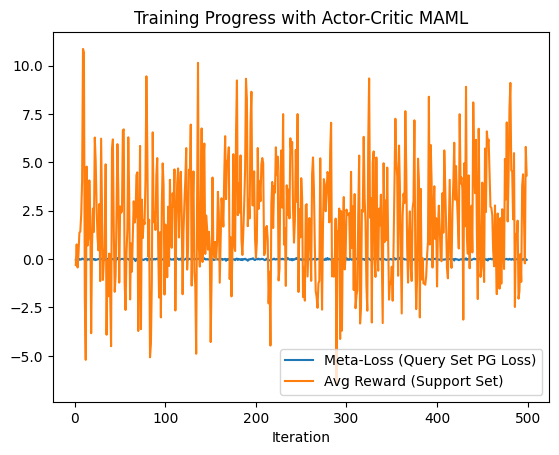

In [24]:
policy = train(inner_lr=0.1,        # Inner LR is often smaller now
               outer_lr=0.01,       # Meta LR can also be adjusted
               critic_lr=0.01,       # New critic learning rate
               inner_steps=1,
               meta_batch_size=20,
               max_episode_len=200
)


In [25]:
env = HalfCheetahBackward()
evaluate(policy, env, num_episodes=10)

Mean Reward: 35.751555314854535


In [26]:
show_video('./Final_Evaluation.mp4')